### Load the libraries needed

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

### Load the data

In [2]:
titanic = sns.load_dataset("titanic")
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### Information about data

In [3]:
# describe function to get numerical info about data
titanic.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
# information about the data
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [5]:
# check number of null values
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

### Feature selection

In [6]:
features = ["pclass", "sex", "fare", "embarked", "age"]
target = ["survived"]

### Handle Missing Values

In [7]:
# import simple imputer
from sklearn.impute import SimpleImputer

In [8]:
# median imputer for numerical values
imp_median = SimpleImputer(strategy="median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])

# imputer for categorical values
imp_freq = SimpleImputer(strategy="most_frequent")
titanic[["embarked"]] = imp_freq.fit_transform(titanic[["embarked"]])

In [9]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

### Feature Encoding

In [10]:
# import label encoder
from sklearn.preprocessing import LabelEncoder

# create object
le = LabelEncoder()

# perform encoding
titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])

In [11]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,Third,man,True,NaN,Southampton,no,False
1,1,1,0,38.0,1,0,71.2833,0,First,woman,False,C,Cherbourg,yes,False
2,1,3,0,26.0,0,0,7.9250,2,Third,woman,False,NaN,Southampton,yes,True
3,1,1,0,35.0,1,0,53.1000,2,First,woman,False,C,Southampton,yes,False
4,0,3,1,35.0,0,0,8.0500,2,Third,man,True,NaN,Southampton,no,True


### Split the data into training and testing part

In [12]:
# dependent variable
x = titanic[features]
x.head()

,pclass,sex,fare,embarked,age
0,3,1,7.2500,2,22.0
1,1,0,71.2833,0,38.0
2,3,0,7.9250,2,26.0
3,1,0,53.1000,2,35.0
4,3,1,8.0500,2,35.0


In [13]:
# independent variable
y = titanic[target]
y.head()

,survived
0,0
1,1
2,1
3,1
4,0


In [14]:
# train test split
train_x, test_x, train_y, test_y = train_test_split(x, y, test_size=0.2, random_state = 42)

In [15]:
len(train_x), len(test_x), len(train_y), len(test_y)

(712, 179, 712, 179)

### Train and Evaluate Model

In [16]:
# import decision tree classifier
from sklearn.tree import DecisionTreeClassifier

In [17]:
# create object
model = DecisionTreeClassifier()

In [18]:
# train model
model.fit(train_x, train_y)

DecisionTreeClassifier()

In [19]:
# predict values
y_pred = model.predict(test_x)
y_pred

array([0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 1])

In [20]:
# Evaluation
from sklearn.metrics import accuracy_score
print("Accuracy: ", accuracy_score(test_y, y_pred))

Accuracy:  0.770949720670391


### Plot decison tree

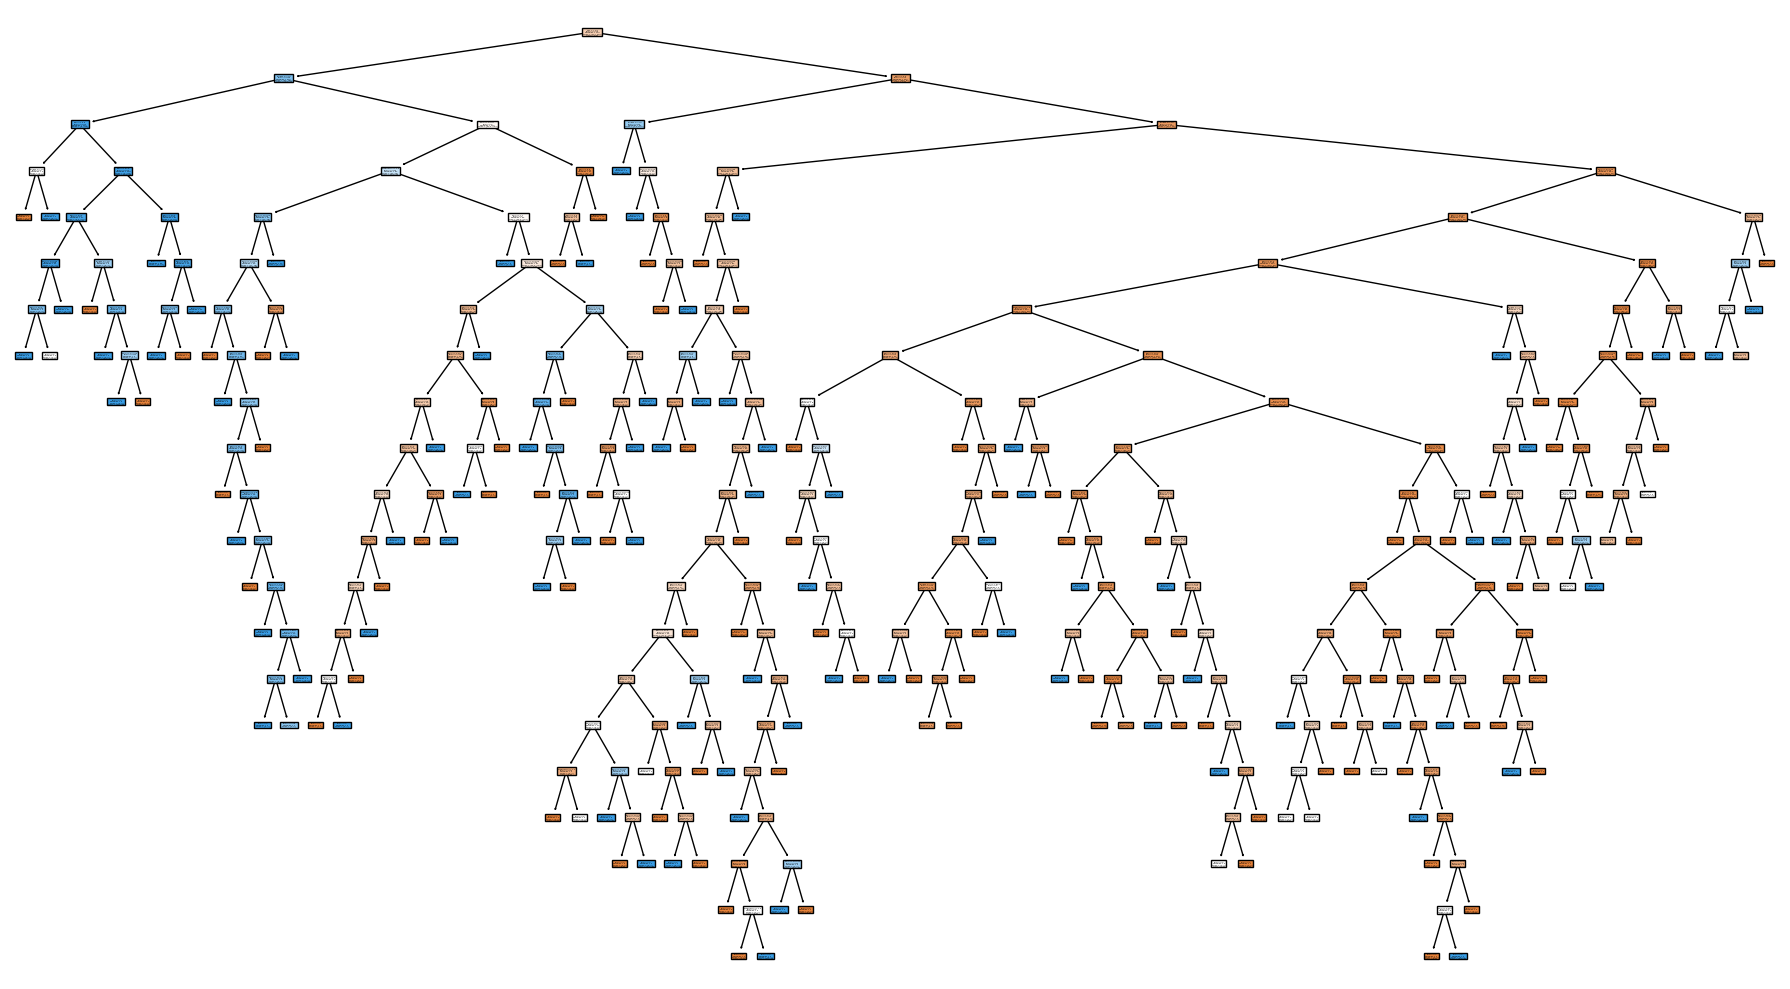

In [21]:
# import plot tree
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))
plot_tree(
    model, 
    feature_names=x.columns,
    class_names=["Died", "Survived"],
    filled=True
)
plt.tight_layout()
plt.show()

### Decision Tree with pre-pruning

In [22]:
# max depth values
max_depths = [2, 3, 4, 5, 6, 7, 8, 9, 10]

for depth in max_depths:
    model = DecisionTreeClassifier(max_depth=depth)
    model.fit(train_x, train_y)
    acc = model.score(test_x, test_y)
    print(f"for depth={depth}, accuracy={acc}")

for depth=2, accuracy=0.7653631284916201
for depth=3, accuracy=0.7988826815642458
for depth=4, accuracy=0.7988826815642458
for depth=5, accuracy=0.7988826815642458
for depth=6, accuracy=0.8044692737430168
for depth=7, accuracy=0.7932960893854749
for depth=8, accuracy=0.7932960893854749
for depth=9, accuracy=0.7988826815642458
for depth=10, accuracy=0.7932960893854749


In [23]:
# min sample splits
min_samples_split = [5, 10, 15, 20, 25, 30]

for split in min_samples_split:
    model = DecisionTreeClassifier(max_depth=6, min_samples_split=split)
    model.fit(train_x, train_y)
    acc = model.score(test_x, test_y)
    print(f"for sample split={split}, accuracy={acc}")

for sample split=5, accuracy=0.8044692737430168
for sample split=10, accuracy=0.8100558659217877
for sample split=15, accuracy=0.8044692737430168
for sample split=20, accuracy=0.8044692737430168
for sample split=25, accuracy=0.7988826815642458
for sample split=30, accuracy=0.7877094972067039


### Decision Tree with post-pruning

In [24]:
# full tree
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(train_x, train_y)

DecisionTreeClassifier(random_state=42)

In [25]:
path = full_tree.cost_complexity_pruning_path(train_x, train_y)
ccp_alphas = path.ccp_alphas

print(ccp_alphas)

[0.00000000e+00 0.00000000e+00 6.68806849e-05 1.45921494e-04
 1.84428555e-04 2.00642055e-04 2.34082397e-04 2.34082397e-04
 3.51123596e-04 4.68164794e-04 4.68164794e-04 5.61797753e-04
 6.24219725e-04 6.67991230e-04 7.02247191e-04 7.02247191e-04
 8.19288390e-04 8.19288390e-04 8.32292967e-04 8.42696629e-04
 8.42696629e-04 8.42696629e-04 8.94231048e-04 8.99610781e-04
 9.24769963e-04 9.36329588e-04 9.36329588e-04 9.36329588e-04
 9.88347898e-04 1.00253471e-03 1.05337079e-03 1.07400895e-03
 1.08038029e-03 1.11865144e-03 1.12359551e-03 1.12359551e-03
 1.13139825e-03 1.17041199e-03 1.18841832e-03 1.22566125e-03
 1.22893258e-03 1.22893258e-03 1.24361593e-03 1.24843945e-03
 1.27565833e-03 1.30996111e-03 1.33761370e-03 1.37044603e-03
 1.46301498e-03 1.47927070e-03 1.51142557e-03 1.54072312e-03
 1.56675436e-03 1.60434338e-03 1.66892062e-03 1.76144762e-03
 1.86751451e-03 2.10674157e-03 2.34082397e-03 2.41226470e-03
 2.64273538e-03 2.69412911e-03 3.43770913e-03 3.56327570e-03
 5.47433606e-03 9.055400

In [26]:
# train model for all alphas
trees = []

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    model.fit(train_x, train_y)
    trees.append((model, alpha))

In [27]:
# find best accuracy and corresponding best alpha
best_acc = 0
best_alpha = 0

for model, alpha in trees:
    curr_acc = model.score(test_x, test_y)
    if curr_acc > best_acc:
        best_acc = curr_acc
        best_alpha = alpha

print(best_alpha, best_acc)

0.0015407231242023183 0.8379888268156425


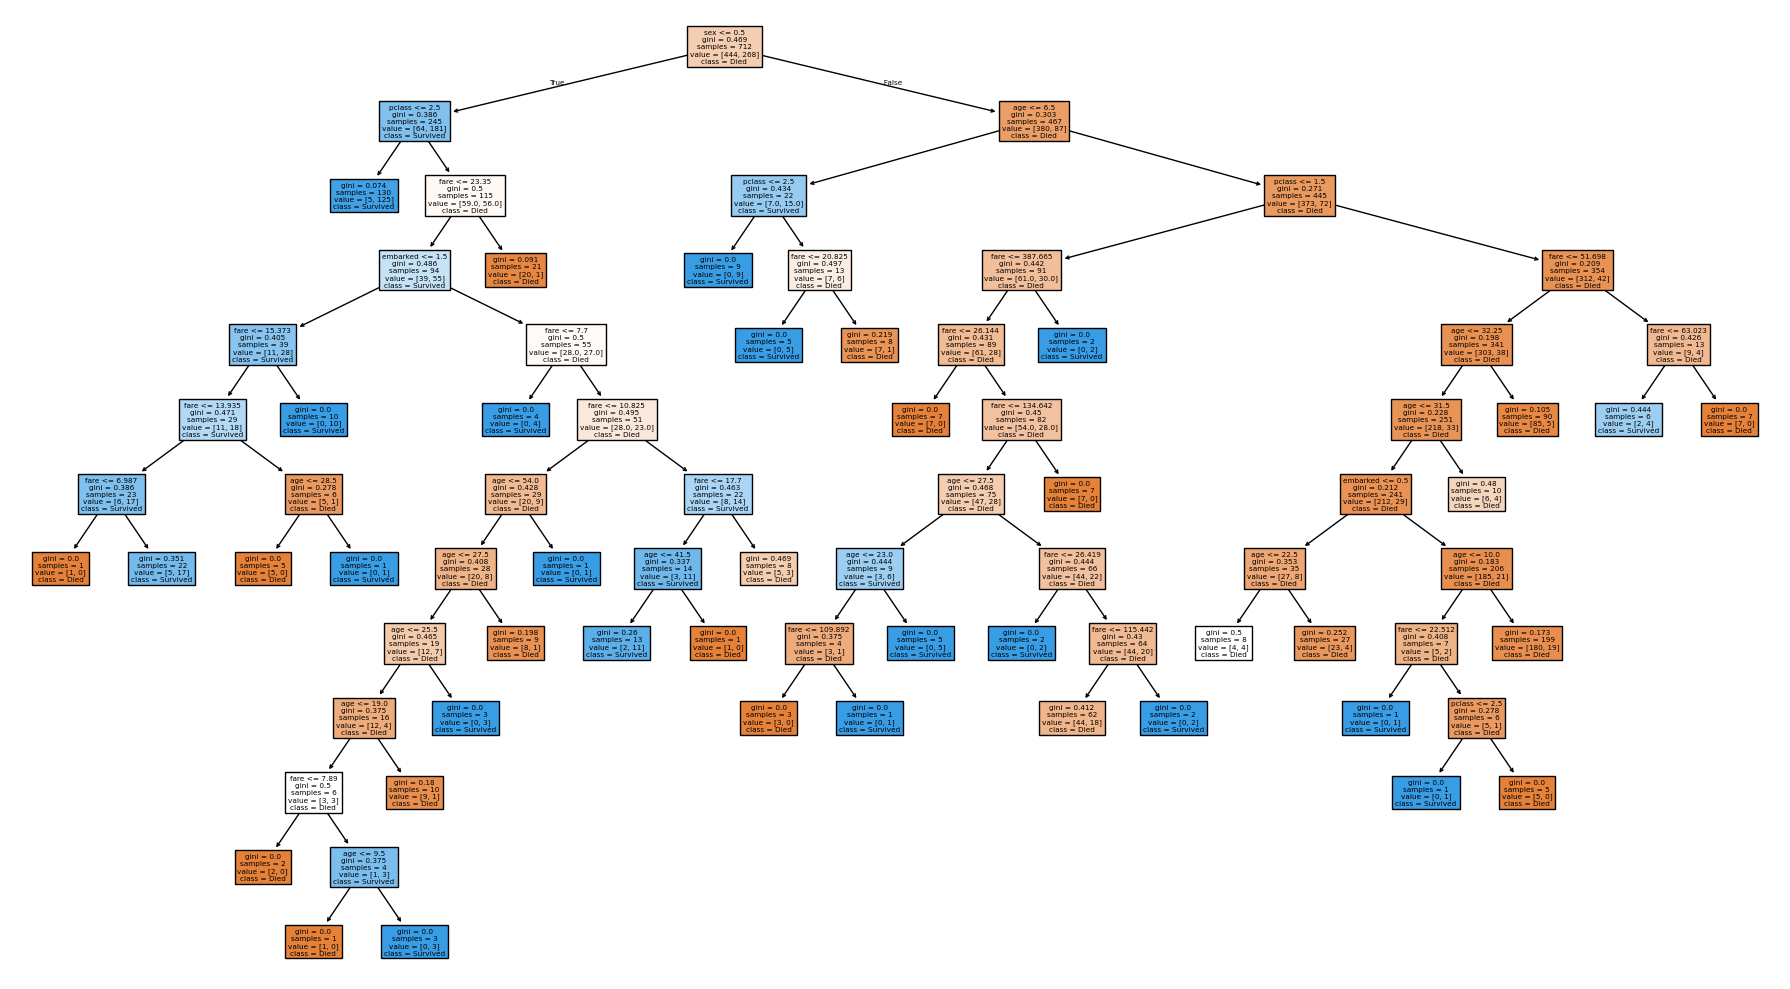

In [28]:
# best model
best_model = DecisionTreeClassifier(ccp_alpha=best_alpha)
best_model.fit(train_x, train_y)

# plot best model
plt.figure(figsize=(18, 10))
plot_tree(
    best_model, 
    feature_names=x.columns,
    class_names=["Died", "Survived"],
    filled=True
)
plt.tight_layout()
plt.show()